Epoch 0: D Loss: 1.7622, G Loss: -0.2884, G Grad Norm^2: 0.011922
Epoch 100: D Loss: 0.7905, G Loss: -0.3273, G Grad Norm^2: 0.150702
Epoch 200: D Loss: 1.0072, G Loss: -0.4566, G Grad Norm^2: 1.159573
Epoch 300: D Loss: 1.0315, G Loss: -0.4593, G Grad Norm^2: 0.650790
Epoch 400: D Loss: 1.0444, G Loss: -0.4629, G Grad Norm^2: 0.630281
Epoch 500: D Loss: 1.1753, G Loss: -0.5922, G Grad Norm^2: 25.374719
Epoch 600: D Loss: 1.2044, G Loss: -0.6078, G Grad Norm^2: 21.176760
Epoch 700: D Loss: 1.2963, G Loss: -0.6566, G Grad Norm^2: 9.500509
Epoch 800: D Loss: 1.3180, G Loss: -0.6591, G Grad Norm^2: 11.238846
Epoch 900: D Loss: 1.3412, G Loss: -0.6717, G Grad Norm^2: 8.863543
Epoch 1000: D Loss: 1.3430, G Loss: -0.6692, G Grad Norm^2: 9.649733
Epoch 1100: D Loss: 1.3561, G Loss: -0.6898, G Grad Norm^2: 14.045666
Epoch 1200: D Loss: 1.3656, G Loss: -0.6791, G Grad Norm^2: 10.290961
Epoch 1300: D Loss: 1.3645, G Loss: -0.6813, G Grad Norm^2: 8.205875
Epoch 1400: D Loss: 1.3652, G Loss: -0.67

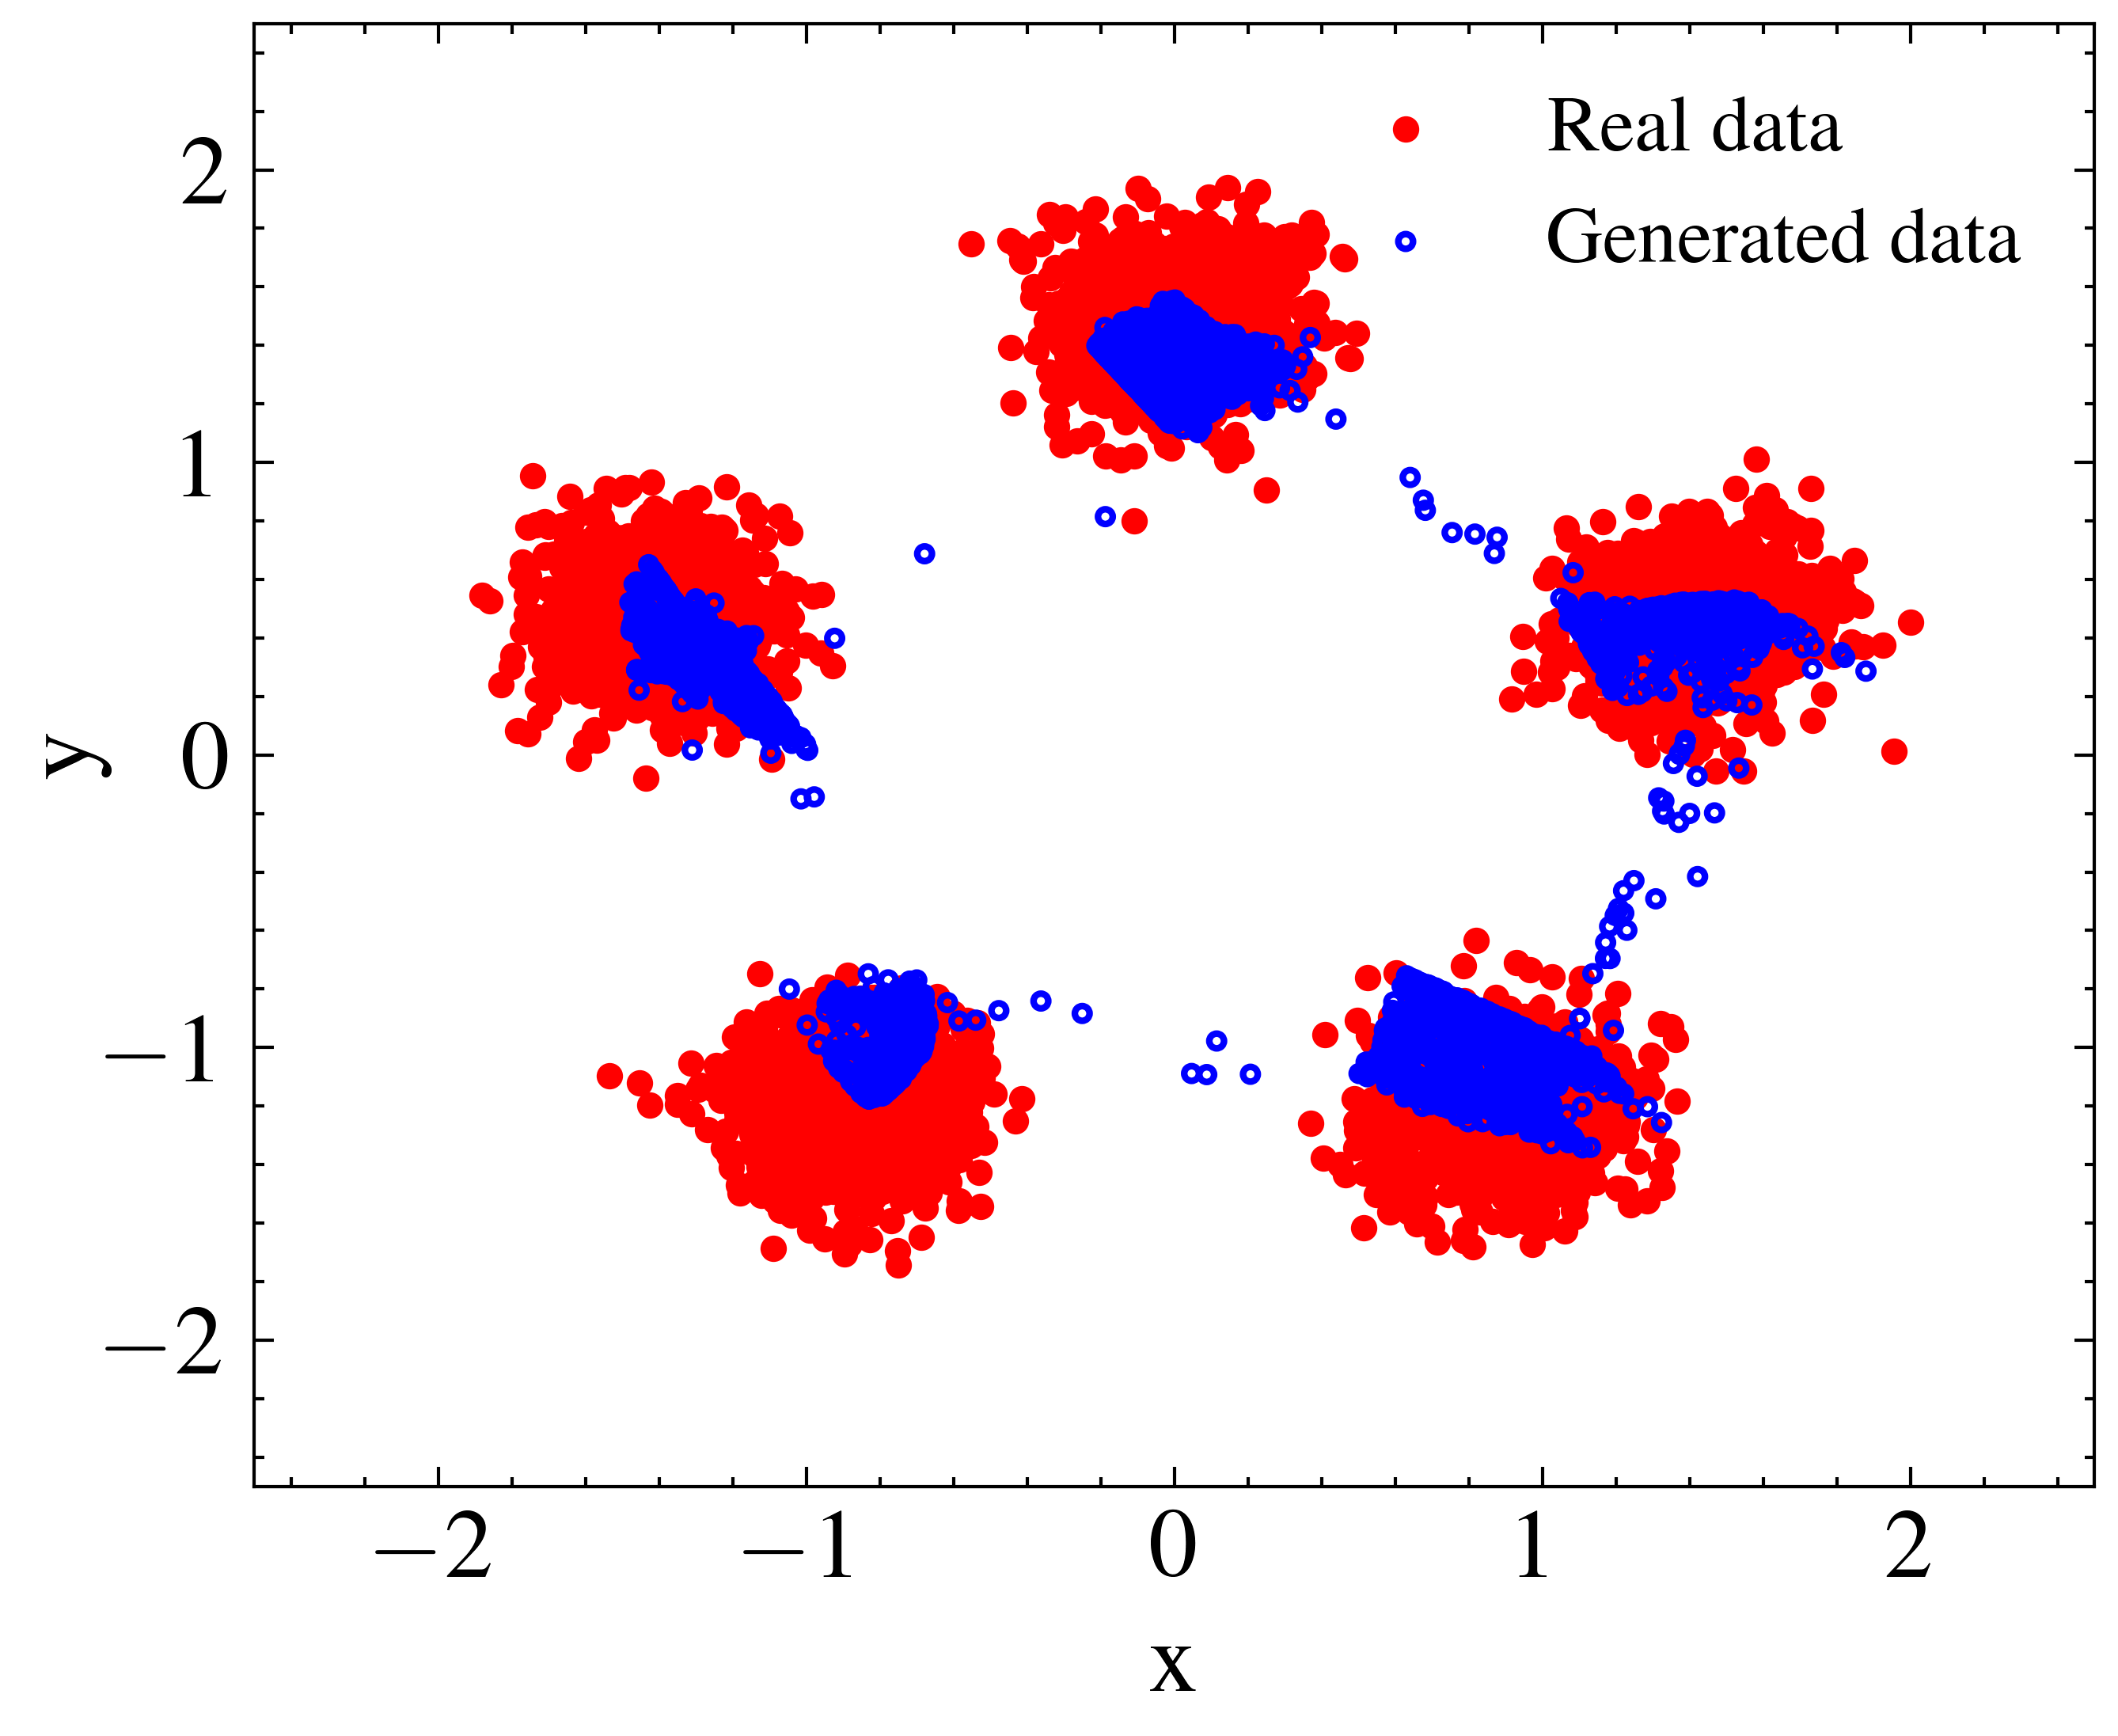


--- GAN 质量评价指标 ---
1-NN 分类精度（越接近0.5越好）: 1.0000
Coverage（真实样本被覆盖比例）: 0.6974
Precision（生成样本落入真实密度区域比例）: 0.9924


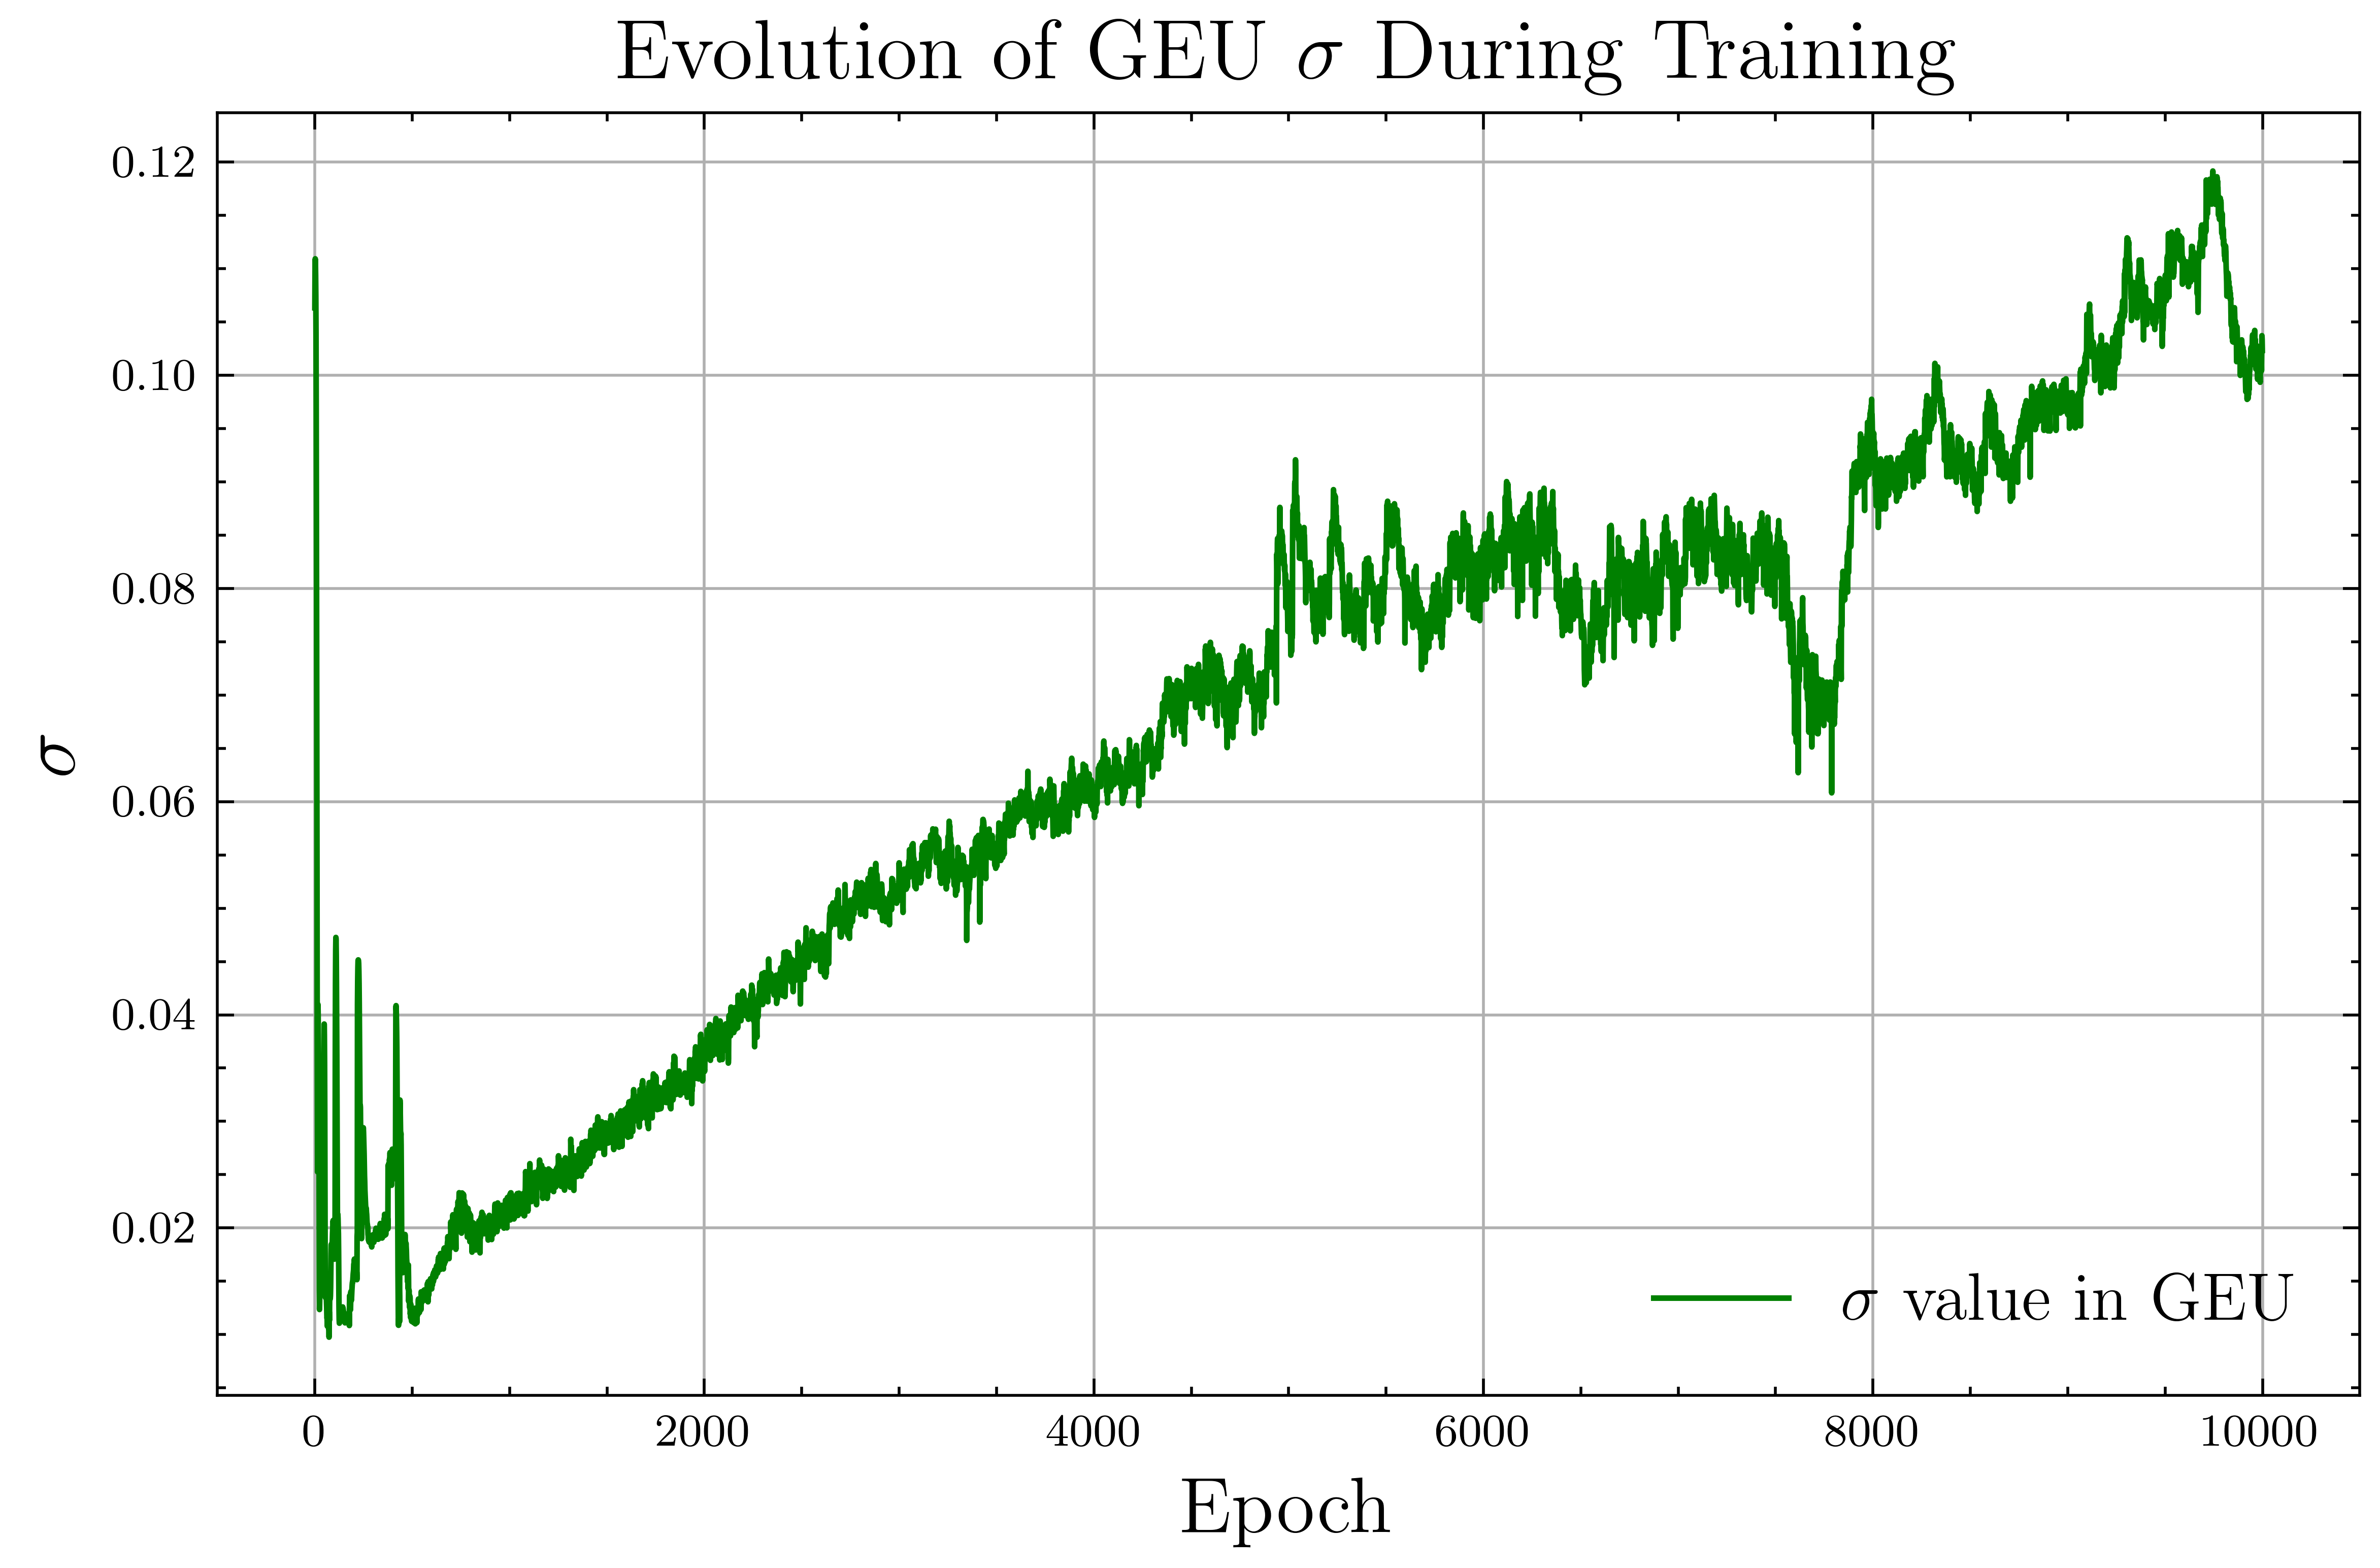

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
import scienceplots
# 设置随机数种子
seed = 742###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class GEU(nn.Module):
    def __init__(self, init_sigma=0.1):  # 建议默认值就写 1.0（浮点数）
        super(GEU, self).__init__()
        # 明确指定为 float32 类型，并包装成 nn.Parameter
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))

    def forward(self, input):
        # 加入一个防止 sigma 为 0 的 epsilon（可选但推荐）
        eps = 1e-6
        sigma_safe = self.sigma + eps
        output = (1 + torch.erf(input / (torch.sqrt(torch.tensor(2.0)) * sigma_safe))) / 2
        return output

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.GEU = GEU()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.GEU(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 10000
X_train = genGauss(1000, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

epoch_generator_grad_norm = []
epoch_sigma_values = []

for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    batch_generator_grad_norm = []  # ← 必须添加这一行
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        # 重新生成图像（因为上面的fake_img已经detach了）
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        # 直接使用判别器损失的相反数来训练生成器
        # 这将使生成器尝试最大化d_fake，欺骗判别器认为生成的样本是真实的
        g_loss = torch.mean(torch.log(1 - d_fake + 1e-8))

        g_optimizer.zero_grad()
        g_loss.backward()
        total_norm = 0.0
        for p in generator.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2) ** 2  # L2 norm squared
                total_norm += param_norm.item()
        batch_generator_grad_norm.append(total_norm)
        
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))
    epoch_generator_grad_norm.append(np.mean(batch_generator_grad_norm))  # ← 新增记录
    epoch_sigma_values.append(discriminator.GEU.sigma.item())

    # Print losses every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, "
              f"G Loss: {np.mean(batch_generator_loss):.4f}, "
              f"G Grad Norm^2: {np.mean(batch_generator_grad_norm):.6f}")
        
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['science','ieee'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(5000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
#ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
import numpy as np

def evaluate_gan_quality(X_real, X_fake, eps=0.1):
    """
    评价 GAN 的输出质量，使用：
    - 1-NN 分类精度
    - Coverage 分数
    - Precision 分数（生成数据落入真实数据附近）

    参数：
    - X_real: (N, d) 真实样本
    - X_fake: (M, d) 生成样本
    - eps: 覆盖的距离阈值

    返回：
    - results: dict 包含各类指标
    """
    X_real = X_real.cpu().detach().numpy() if torch.is_tensor(X_real) else X_real
    X_fake = X_fake.cpu().detach().numpy() if torch.is_tensor(X_fake) else X_fake

    # ------------------------------
    # 1. 1-NN Classification Accuracy
    # ------------------------------
    X_all = np.concatenate([X_real, X_fake], axis=0)
    y_all = np.concatenate([np.ones(len(X_real)), np.zeros(len(X_fake))])

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_all, y_all)
    y_pred = knn.predict(X_all)
    acc = accuracy_score(y_all, y_pred)
    one_nn_acc = max(acc, 1 - acc)  # 对称性，靠近 0.5 越好

    # ------------------------------
    # 2. Coverage: 真实数据被生成样本覆盖的比例
    # ------------------------------
    dists_real_to_fake = cdist(X_real, X_fake)  # (N_real, N_fake)
    min_dists_real = np.min(dists_real_to_fake, axis=1)
    coverage_score = np.mean(min_dists_real < eps)

    # ------------------------------
    # 3. Precision: 生成样本落在真实样本附近的比例
    # ------------------------------
    dists_fake_to_real = cdist(X_fake, X_real)
    min_dists_fake = np.min(dists_fake_to_real, axis=1)
    precision_score = np.mean(min_dists_fake < eps)

    return {
        '1NN_acc': one_nn_acc,
        'Coverage': coverage_score,
        'Precision': precision_score
    }

# 调用评价函数
metrics = evaluate_gan_quality(X_train, samples, eps=0.1)

print("\n--- GAN 质量评价指标 ---")
print(f"1-NN 分类精度（越接近0.5越好）: {metrics['1NN_acc']:.4f}")
print(f"Coverage（真实样本被覆盖比例）: {metrics['Coverage']:.4f}")
print(f"Precision（生成样本落入真实密度区域比例）: {metrics['Precision']:.4f}")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 加载 sigma 数据
#epoch_sigma_values = np.load("D:/PRE2023 2025/epoch_sigma_values742.npy")

# 绘图
plt.figure(figsize=(6, 4))
plt.plot(epoch_sigma_values, label=r'$\sigma$ value in GEU', color='green')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel(r'$\sigma$', fontsize=14)
plt.title('Evolution of GEU $\sigma$ During Training', fontsize=15)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
# plt.savefig("D:/PRE2023 2025/sigma742.pdf")  # 可选保存为 PDF
plt.show()

In [4]:
np.save("D:/PRE2023 2025/sample742GEU-2026.npy", samples)
np.save("D:/PRE2023 2025/epoch_generator_grad_normGEU742-2026.npy", epoch_generator_grad_norm)
np.save("D:/PRE2023 2025/epoch_sigma_valuesGEU742-2026.npy", epoch_sigma_values)

Epoch 0: D Loss: 1.5059, G Loss: -0.4359, G Grad Norm^2: 0.005515
Epoch 100: D Loss: 0.7360, G Loss: -0.3512, G Grad Norm^2: 1.960545
Epoch 200: D Loss: 0.9600, G Loss: -0.5543, G Grad Norm^2: 9.305648
Epoch 300: D Loss: 0.8873, G Loss: -0.4081, G Grad Norm^2: 3.111366
Epoch 400: D Loss: 1.1403, G Loss: -0.5490, G Grad Norm^2: 11.011334
Epoch 500: D Loss: 1.2208, G Loss: -0.6252, G Grad Norm^2: 8.321656
Epoch 600: D Loss: 1.2537, G Loss: -0.6258, G Grad Norm^2: 9.670983
Epoch 700: D Loss: 1.3097, G Loss: -0.6726, G Grad Norm^2: 5.583161
Epoch 800: D Loss: 1.3349, G Loss: -0.6839, G Grad Norm^2: 7.427687
Epoch 900: D Loss: 1.3493, G Loss: -0.6838, G Grad Norm^2: 6.573078
Epoch 1000: D Loss: 1.3529, G Loss: -0.6835, G Grad Norm^2: 7.060587
Epoch 1100: D Loss: 1.3632, G Loss: -0.6860, G Grad Norm^2: 6.541017
Epoch 1200: D Loss: 1.3650, G Loss: -0.6887, G Grad Norm^2: 7.505425
Epoch 1300: D Loss: 1.3697, G Loss: -0.6905, G Grad Norm^2: 7.652897
Epoch 1400: D Loss: 1.3743, G Loss: -0.6920, 

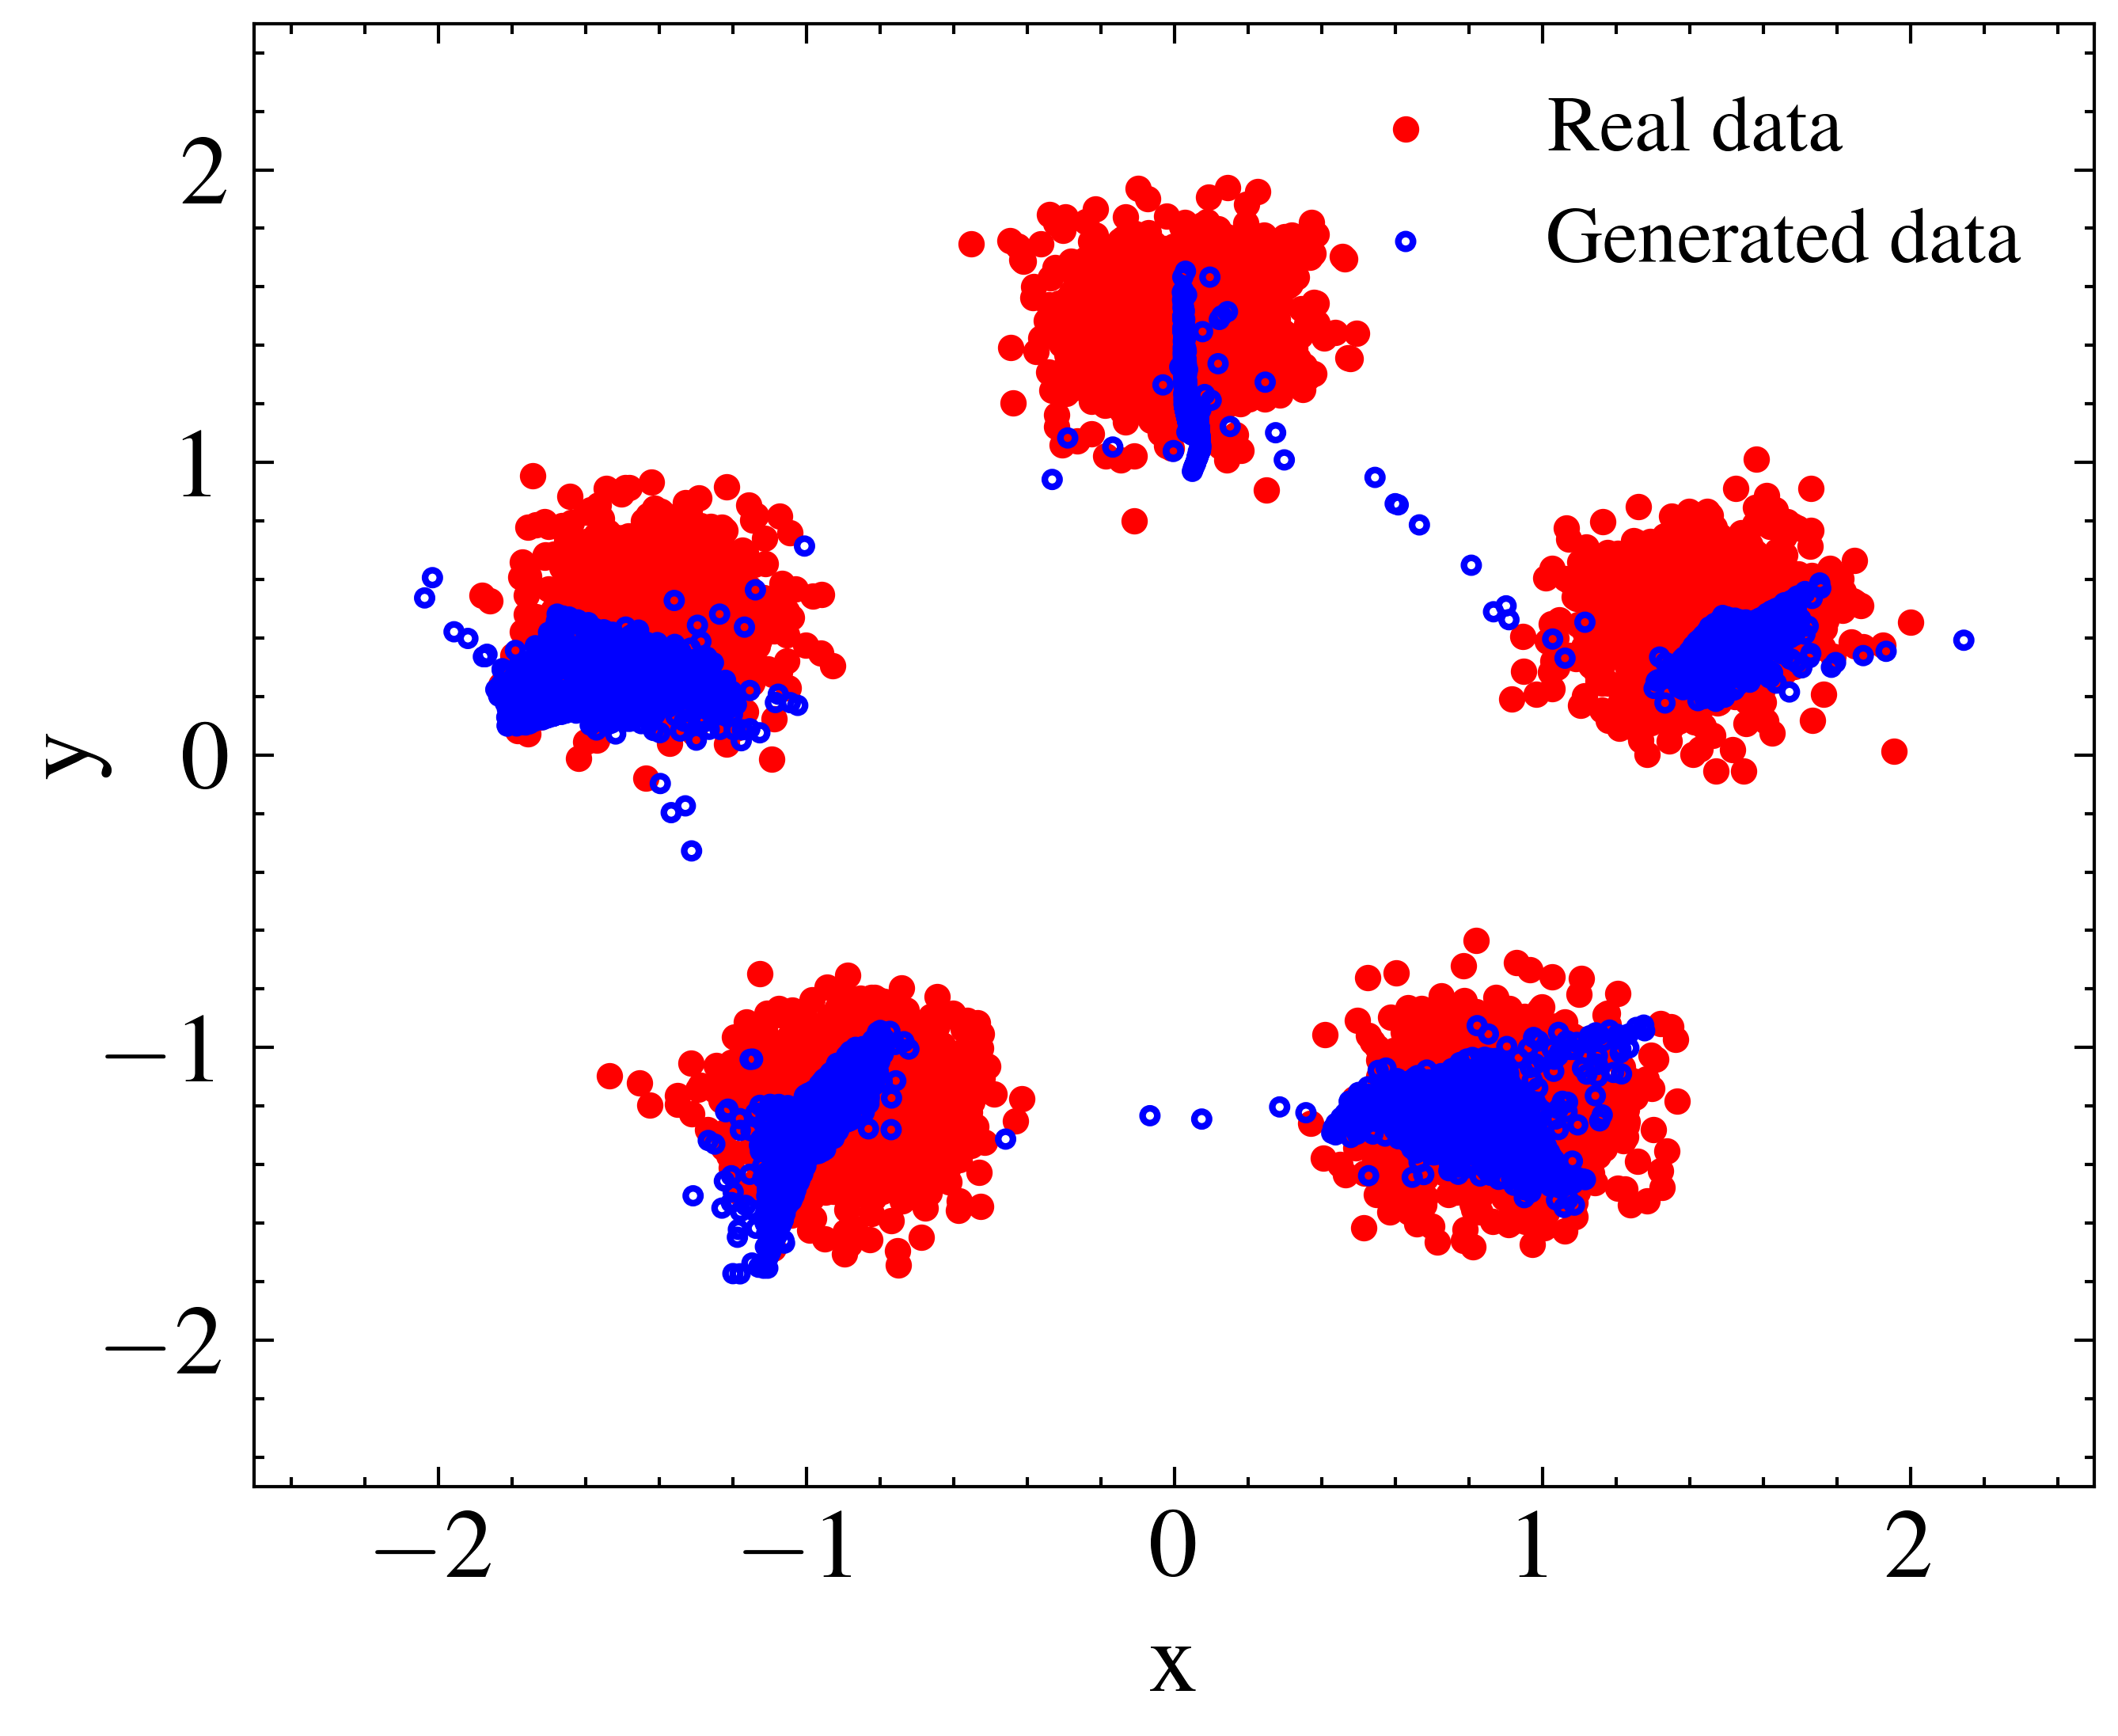


--- GAN 质量评价指标 ---
1-NN 分类精度（越接近0.5越好）: 1.0000
Coverage（真实样本被覆盖比例）: 0.7344
Precision（生成样本落入真实密度区域比例）: 0.9948


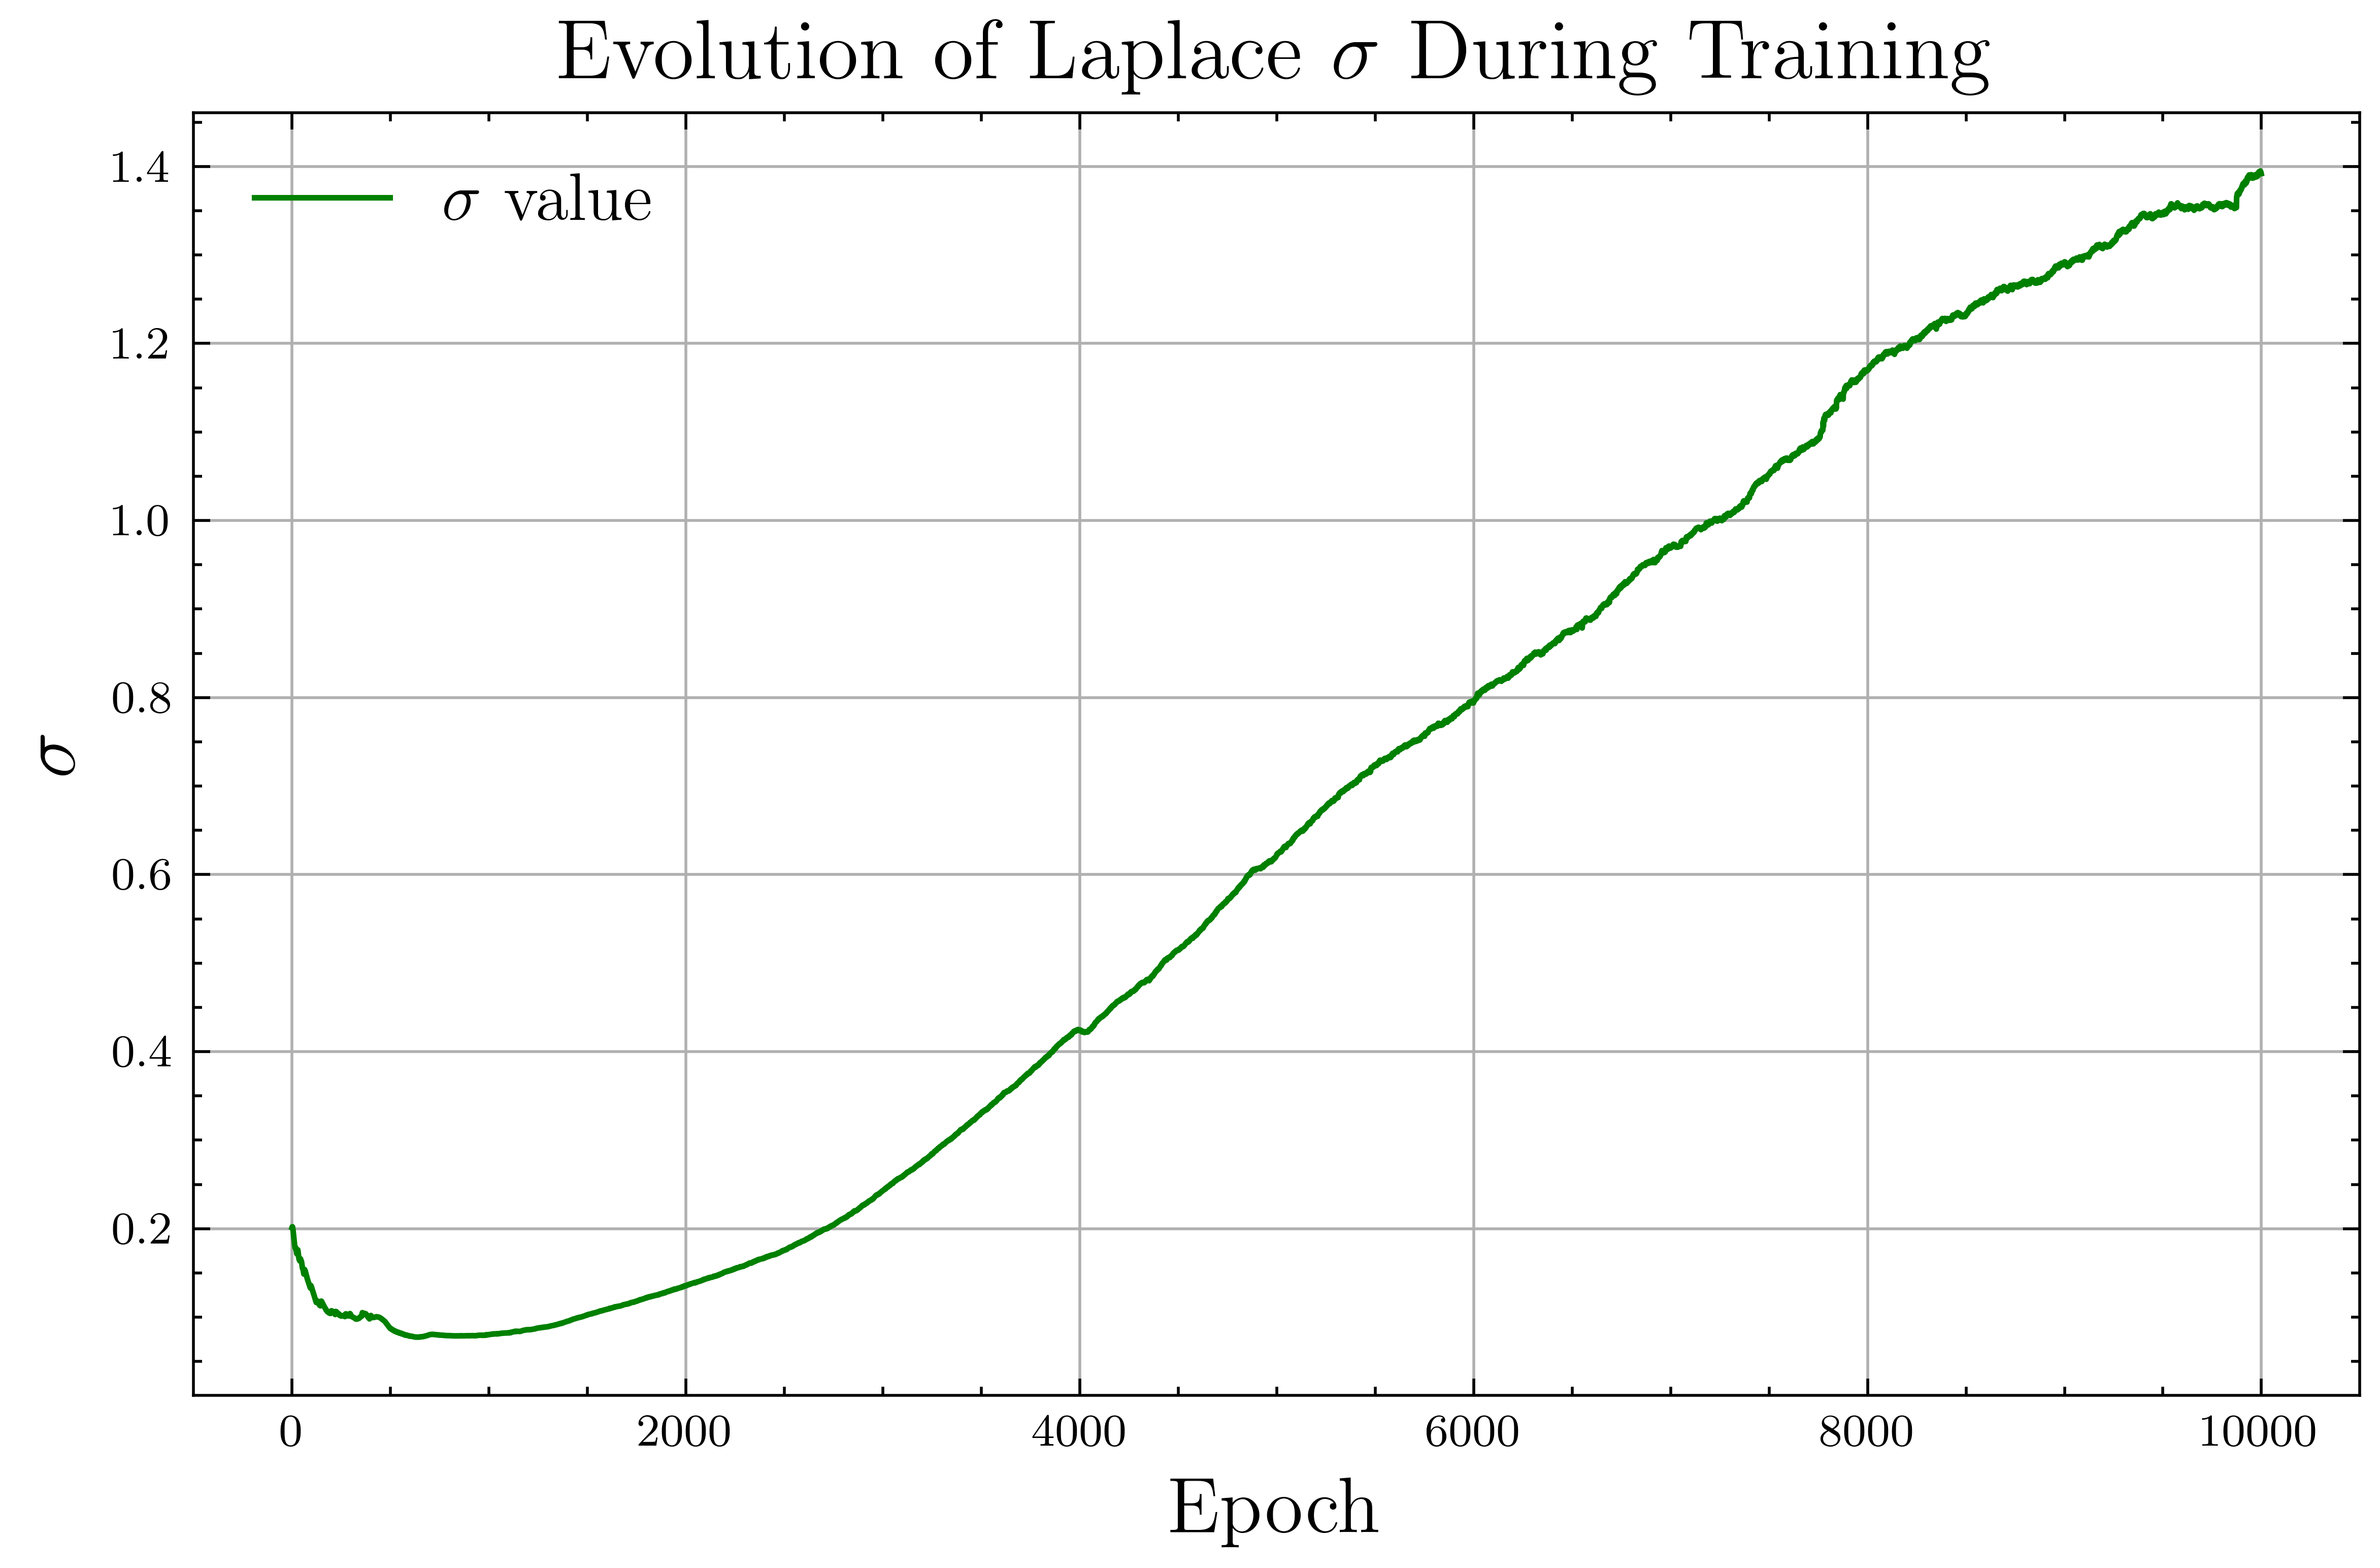

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
import scienceplots
# 设置随机数种子
seed = 742###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class LaplaceCDF(nn.Module):
    def __init__(self, init_sigma=0.2):
        super(LaplaceCDF, self).__init__()
        self.log_sigma = nn.Parameter(
            torch.tensor(np.log(init_sigma), dtype=torch.float32)
        )

    @property
    def sigma(self):
        return torch.exp(self.log_sigma)

    def forward(self, input):
        sigma = self.sigma
        output = torch.where(
            input < 0,
            0.5 * torch.exp(input / sigma),
            1 - 0.5 * torch.exp(-input / sigma)
        )
        return output

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.LaplaceCDF = LaplaceCDF()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.LaplaceCDF(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 10000
X_train = genGauss(1000, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

epoch_generator_grad_norm = []
epoch_sigma_values = []

for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    batch_generator_grad_norm = []  # ← 必须添加这一行
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        # 重新生成图像（因为上面的fake_img已经detach了）
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        # 直接使用判别器损失的相反数来训练生成器
        # 这将使生成器尝试最大化d_fake，欺骗判别器认为生成的样本是真实的
        g_loss = torch.mean(torch.log(1 - d_fake + 1e-8))

        g_optimizer.zero_grad()
        g_loss.backward()
        total_norm = 0.0
        for p in generator.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2) ** 2  # L2 norm squared
                total_norm += param_norm.item()
        batch_generator_grad_norm.append(total_norm)
        
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))
    epoch_generator_grad_norm.append(np.mean(batch_generator_grad_norm))  # ← 新增记录
    epoch_sigma_values.append(discriminator.LaplaceCDF.sigma.item())

    # Print losses every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, "
              f"G Loss: {np.mean(batch_generator_loss):.4f}, "
              f"G Grad Norm^2: {np.mean(batch_generator_grad_norm):.6f}")
        
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['science','ieee'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(5000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
#ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
import numpy as np

def evaluate_gan_quality(X_real, X_fake, eps=0.1):
    """
    评价 GAN 的输出质量，使用：
    - 1-NN 分类精度
    - Coverage 分数
    - Precision 分数（生成数据落入真实数据附近）

    参数：
    - X_real: (N, d) 真实样本
    - X_fake: (M, d) 生成样本
    - eps: 覆盖的距离阈值

    返回：
    - results: dict 包含各类指标
    """
    X_real = X_real.cpu().detach().numpy() if torch.is_tensor(X_real) else X_real
    X_fake = X_fake.cpu().detach().numpy() if torch.is_tensor(X_fake) else X_fake

    # ------------------------------
    # 1. 1-NN Classification Accuracy
    # ------------------------------
    X_all = np.concatenate([X_real, X_fake], axis=0)
    y_all = np.concatenate([np.ones(len(X_real)), np.zeros(len(X_fake))])

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_all, y_all)
    y_pred = knn.predict(X_all)
    acc = accuracy_score(y_all, y_pred)
    one_nn_acc = max(acc, 1 - acc)  # 对称性，靠近 0.5 越好

    # ------------------------------
    # 2. Coverage: 真实数据被生成样本覆盖的比例
    # ------------------------------
    dists_real_to_fake = cdist(X_real, X_fake)  # (N_real, N_fake)
    min_dists_real = np.min(dists_real_to_fake, axis=1)
    coverage_score = np.mean(min_dists_real < eps)

    # ------------------------------
    # 3. Precision: 生成样本落在真实样本附近的比例
    # ------------------------------
    dists_fake_to_real = cdist(X_fake, X_real)
    min_dists_fake = np.min(dists_fake_to_real, axis=1)
    precision_score = np.mean(min_dists_fake < eps)

    return {
        '1NN_acc': one_nn_acc,
        'Coverage': coverage_score,
        'Precision': precision_score
    }

# 调用评价函数
metrics = evaluate_gan_quality(X_train, samples, eps=0.1)

print("\n--- GAN 质量评价指标 ---")
print(f"1-NN 分类精度（越接近0.5越好）: {metrics['1NN_acc']:.4f}")
print(f"Coverage（真实样本被覆盖比例）: {metrics['Coverage']:.4f}")
print(f"Precision（生成样本落入真实密度区域比例）: {metrics['Precision']:.4f}")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 加载 sigma 数据
#epoch_sigma_values = np.load("D:/PRE2023 2025/epoch_sigma_values742.npy")

# 绘图
plt.figure(figsize=(6, 4))
plt.plot(epoch_sigma_values, label=r'$\sigma$ value', color='green')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel(r'$\sigma$', fontsize=14)
plt.title('Evolution of Laplace $\sigma$ During Training', fontsize=15)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
# plt.savefig("D:/PRE2023 2025/sigma742.pdf")  # 可选保存为 PDF
plt.show()

In [2]:
np.save("D:/PRE2023 2025/sample742Lap-2026.npy", samples)
np.save("D:/PRE2023 2025/epoch_generator_grad_normLap742-2026.npy", epoch_generator_grad_norm)
np.save("D:/PRE2023 2025/epoch_sigma_valuesLap742-2026.npy", epoch_sigma_values)

Epoch 0: D Loss: 1.5472, G Loss: -0.4050, G Grad Norm^2: 0.008008
Epoch 100: D Loss: 0.7741, G Loss: -0.3247, G Grad Norm^2: 0.585759
Epoch 200: D Loss: 0.7008, G Loss: -0.3090, G Grad Norm^2: 0.696266
Epoch 300: D Loss: 1.0358, G Loss: -0.4673, G Grad Norm^2: 0.352782
Epoch 400: D Loss: 1.1793, G Loss: -0.5769, G Grad Norm^2: 3.921984
Epoch 500: D Loss: 1.1676, G Loss: -0.5994, G Grad Norm^2: 11.669016
Epoch 600: D Loss: 1.2377, G Loss: -0.6388, G Grad Norm^2: 12.726719
Epoch 700: D Loss: 1.2804, G Loss: -0.6470, G Grad Norm^2: 10.066823
Epoch 800: D Loss: 1.2905, G Loss: -0.6576, G Grad Norm^2: 14.079479
Epoch 900: D Loss: 1.2969, G Loss: -0.6520, G Grad Norm^2: 10.917483
Epoch 1000: D Loss: 1.3294, G Loss: -0.6693, G Grad Norm^2: 8.827003
Epoch 1100: D Loss: 1.3351, G Loss: -0.6734, G Grad Norm^2: 9.145373
Epoch 1200: D Loss: 1.3397, G Loss: -0.6784, G Grad Norm^2: 10.034964
Epoch 1300: D Loss: 1.3504, G Loss: -0.6894, G Grad Norm^2: 17.887991
Epoch 1400: D Loss: 1.3399, G Loss: -0.

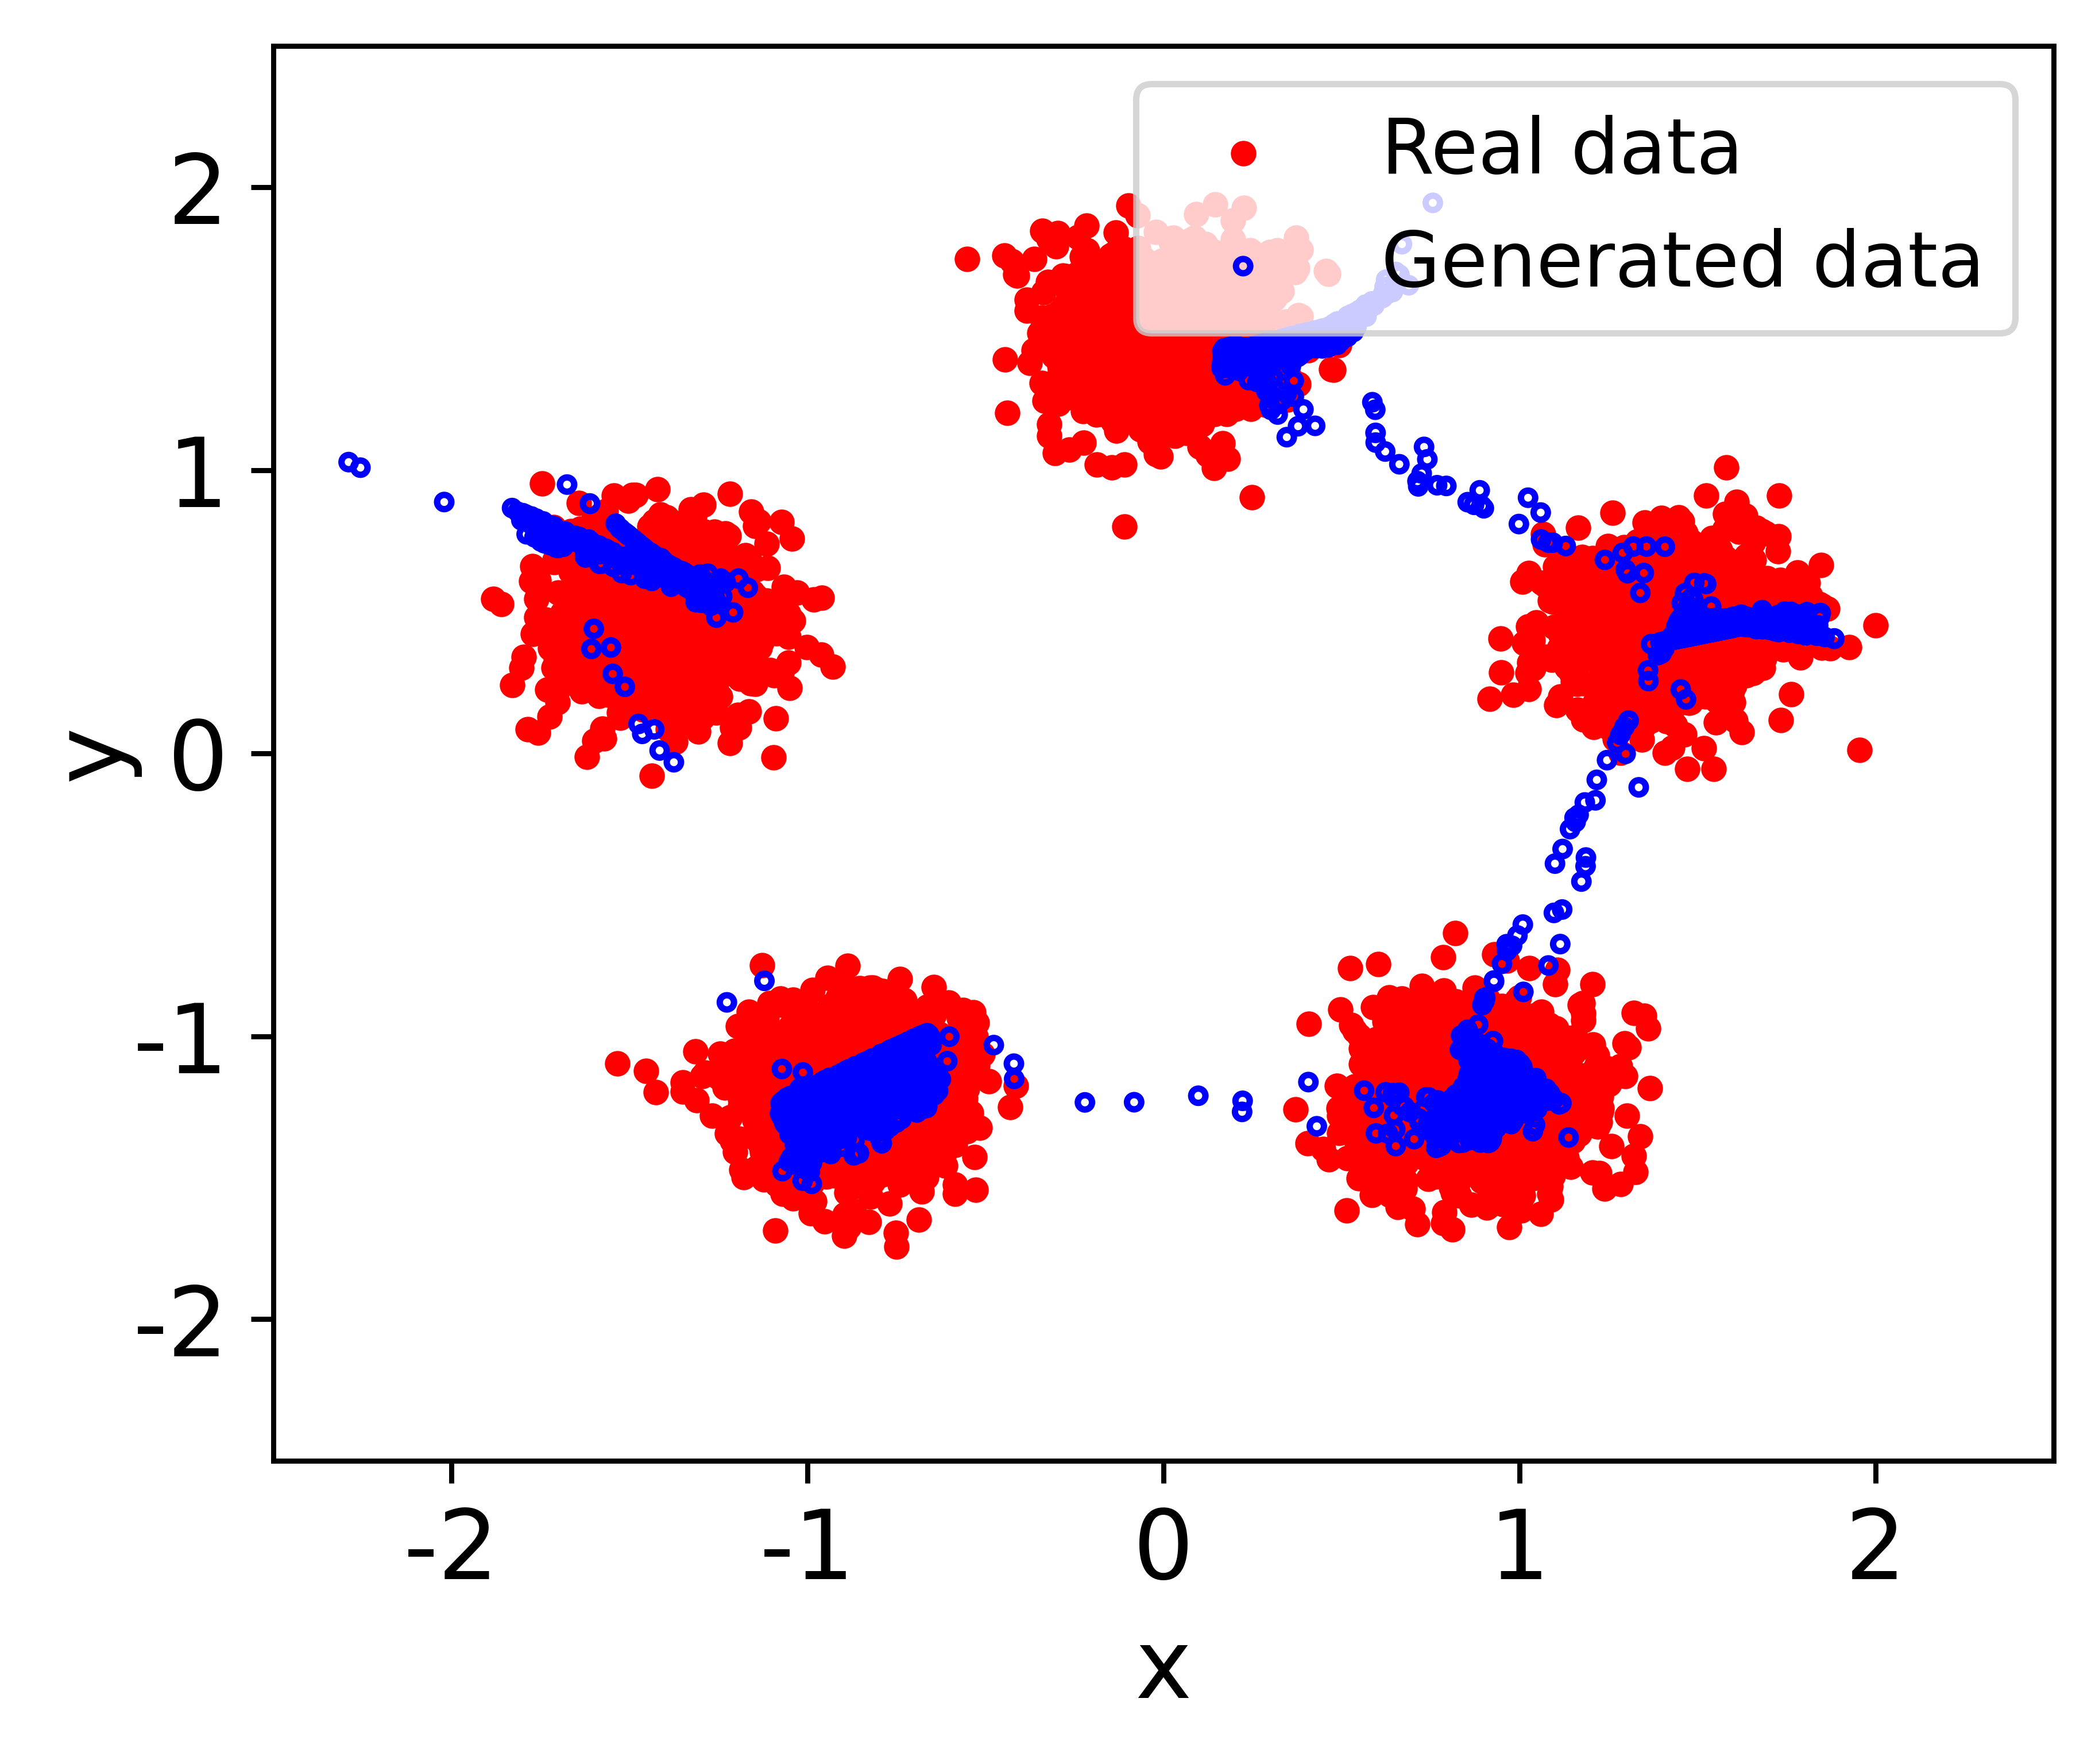


--- GAN 质量评价指标 ---
1-NN 分类精度（越接近0.5越好）: 1.0000
Coverage（真实样本被覆盖比例）: 0.6504
Precision（生成样本落入真实密度区域比例）: 0.9820


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl

# 设置随机数种子
seed = 742###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Vsig(nn.Module):
    def __init__(self, init_sigma=0.1):
        super(Vsig, self).__init__()
        self.log_sigma = nn.Parameter(
            torch.tensor(np.log(init_sigma), dtype=torch.float32)
        )

    @property
    def sigma(self):
        return torch.exp(self.log_sigma)

    def forward(self, input):
        sigma = self.sigma
        output = 1.0 / (1.0 + torch.exp(-input / sigma))
        return output

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.vsigmoid = Vsig()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.vsigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 10000
X_train = genGauss(1000, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []
epoch_generator_grad_norm = []
epoch_sigma_values = []

for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    batch_generator_grad_norm = []  # ← 必须添加这一行
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        # 重新生成图像（因为上面的fake_img已经detach了）
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        # 直接使用判别器损失的相反数来训练生成器
        # 这将使生成器尝试最大化d_fake，欺骗判别器认为生成的样本是真实的
        g_loss = torch.mean(torch.log(1 - d_fake + 1e-8))

        g_optimizer.zero_grad()
        g_loss.backward()
        total_norm = 0.0
        for p in generator.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2) ** 2  # L2 norm squared
                total_norm += param_norm.item()
        batch_generator_grad_norm.append(total_norm)
        
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))
    epoch_generator_grad_norm.append(np.mean(batch_generator_grad_norm))  # ← 新增记录
    epoch_sigma_values.append(discriminator.vsigmoid.sigma.item())

    # Print losses every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, "
              f"G Loss: {np.mean(batch_generator_loss):.4f}, "
              f"G Grad Norm^2: {np.mean(batch_generator_grad_norm):.6f}")
        
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
#plt.style.use(['science','ieee'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(5000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
#ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
import numpy as np

def evaluate_gan_quality(X_real, X_fake, eps=0.1):
    """
    评价 GAN 的输出质量，使用：
    - 1-NN 分类精度
    - Coverage 分数
    - Precision 分数（生成数据落入真实数据附近）

    参数：
    - X_real: (N, d) 真实样本
    - X_fake: (M, d) 生成样本
    - eps: 覆盖的距离阈值

    返回：
    - results: dict 包含各类指标
    """
    X_real = X_real.cpu().detach().numpy() if torch.is_tensor(X_real) else X_real
    X_fake = X_fake.cpu().detach().numpy() if torch.is_tensor(X_fake) else X_fake

    # ------------------------------
    # 1. 1-NN Classification Accuracy
    # ------------------------------
    X_all = np.concatenate([X_real, X_fake], axis=0)
    y_all = np.concatenate([np.ones(len(X_real)), np.zeros(len(X_fake))])

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_all, y_all)
    y_pred = knn.predict(X_all)
    acc = accuracy_score(y_all, y_pred)
    one_nn_acc = max(acc, 1 - acc)  # 对称性，靠近 0.5 越好

    # ------------------------------
    # 2. Coverage: 真实数据被生成样本覆盖的比例
    # ------------------------------
    dists_real_to_fake = cdist(X_real, X_fake)  # (N_real, N_fake)
    min_dists_real = np.min(dists_real_to_fake, axis=1)
    coverage_score = np.mean(min_dists_real < eps)

    # ------------------------------
    # 3. Precision: 生成样本落在真实样本附近的比例
    # ------------------------------
    dists_fake_to_real = cdist(X_fake, X_real)
    min_dists_fake = np.min(dists_fake_to_real, axis=1)
    precision_score = np.mean(min_dists_fake < eps)

    return {
        '1NN_acc': one_nn_acc,
        'Coverage': coverage_score,
        'Precision': precision_score
    }

# 调用评价函数
metrics = evaluate_gan_quality(X_train, samples, eps=0.1)

print("\n--- GAN 质量评价指标 ---")
print(f"1-NN 分类精度（越接近0.5越好）: {metrics['1NN_acc']:.4f}")
print(f"Coverage（真实样本被覆盖比例）: {metrics['Coverage']:.4f}")
print(f"Precision（生成样本落入真实密度区域比例）: {metrics['Precision']:.4f}")

In [4]:
np.save("D:/PRE2023 2025/sample742vsig-2026.npy", samples)
np.save("D:/PRE2023 2025/epoch_generator_grad_normvsig742-2026.npy", epoch_generator_grad_norm)
np.save("D:/PRE2023 2025/epoch_sigma_valuesvsig742-2026.npy", epoch_sigma_values)

Epoch 0: D Loss: 1.3901, G Loss: -0.6555, G Grad Norm^2: 0.000222
Epoch 100: D Loss: 1.3595, G Loss: -0.6661, G Grad Norm^2: 7.284187
Epoch 200: D Loss: 0.5702, G Loss: -0.1943, G Grad Norm^2: 0.829309
Epoch 300: D Loss: 0.6127, G Loss: -0.2296, G Grad Norm^2: 0.073276
Epoch 400: D Loss: 0.4289, G Loss: -0.1553, G Grad Norm^2: 2.447523
Epoch 500: D Loss: 0.7159, G Loss: -0.2883, G Grad Norm^2: 0.096253
Epoch 600: D Loss: 1.0087, G Loss: -0.4045, G Grad Norm^2: 2.240704
Epoch 700: D Loss: 0.5558, G Loss: -0.1913, G Grad Norm^2: 0.107151
Epoch 800: D Loss: 0.9393, G Loss: -0.4811, G Grad Norm^2: 0.482515
Epoch 900: D Loss: 0.7600, G Loss: -0.3493, G Grad Norm^2: 0.108320
Epoch 1000: D Loss: 0.5821, G Loss: -0.2205, G Grad Norm^2: 0.078234
Epoch 1100: D Loss: 0.6505, G Loss: -0.2133, G Grad Norm^2: 3.658664
Epoch 1200: D Loss: 0.5535, G Loss: -0.1946, G Grad Norm^2: 0.018992
Epoch 1300: D Loss: 0.7410, G Loss: -0.3209, G Grad Norm^2: 0.052856
Epoch 1400: D Loss: 0.7561, G Loss: -0.3194, G

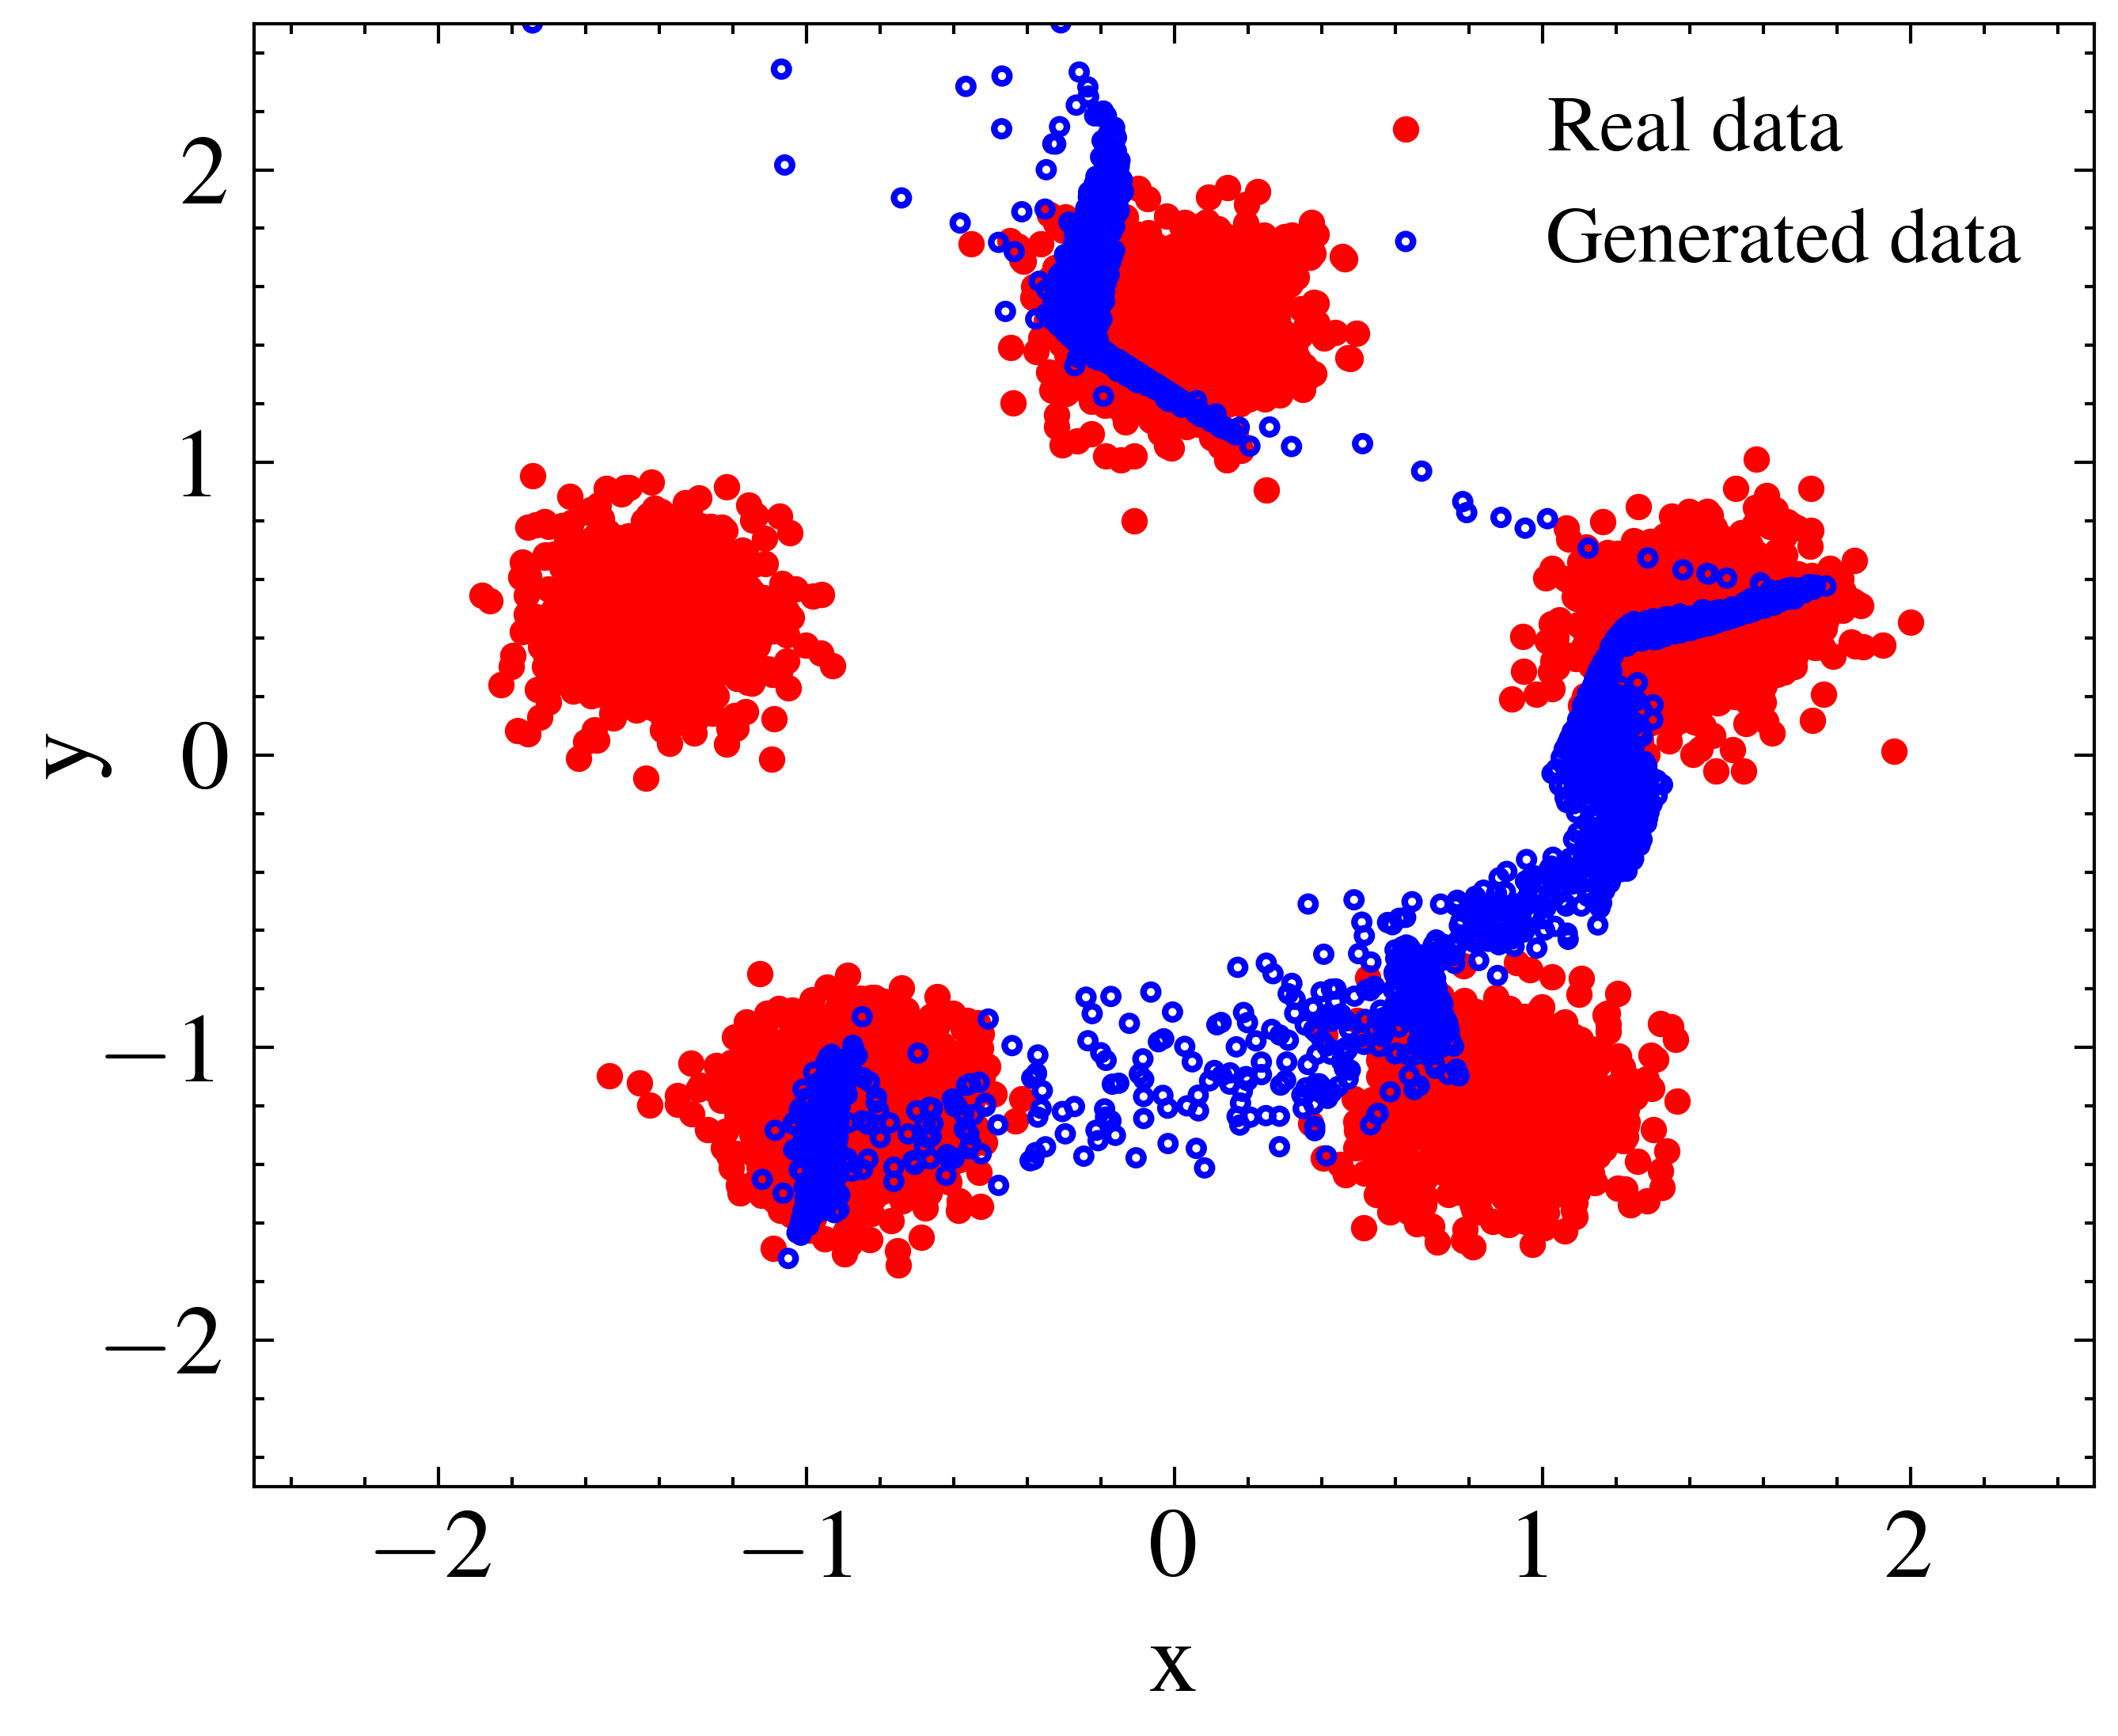


--- GAN 质量评价指标 ---
1-NN 分类精度（越接近0.5越好）: 1.0000
Coverage（真实样本被覆盖比例）: 0.4630
Precision（生成样本落入真实密度区域比例）: 0.9008


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
#import scienceplots
# 设置随机数种子
seed = 742  ###########连续5次随机种子看看是否成功42, 23, 683，83
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 10000
X_train = genGauss(1000, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
epoch_generator_grad_norm = []

for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    batch_generator_grad_norm = []  # ← 必须添加这一行
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        # 重新生成图像（因为上面的fake_img已经detach了）
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        # 直接使用判别器损失的相反数来训练生成器
        # 这将使生成器尝试最大化d_fake，欺骗判别器认为生成的样本是真实的
        g_loss = torch.mean(torch.log(1 - d_fake + 1e-8))

        g_optimizer.zero_grad()
        g_loss.backward()
        total_norm = 0.0
        for p in generator.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2) ** 2  # L2 norm squared
                total_norm += param_norm.item()
        batch_generator_grad_norm.append(total_norm)
        
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))
    epoch_generator_grad_norm.append(np.mean(batch_generator_grad_norm))  # ← 新增记录

    # Print losses every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, "
              f"G Loss: {np.mean(batch_generator_loss):.4f}, "
              f"G Grad Norm^2: {np.mean(batch_generator_grad_norm):.6f}")
        
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['science','ieee'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(5000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
#ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
import numpy as np

def evaluate_gan_quality(X_real, X_fake, eps=0.1):
    """
    评价 GAN 的输出质量，使用：
    - 1-NN 分类精度
    - Coverage 分数
    - Precision 分数（生成数据落入真实数据附近）

    参数：
    - X_real: (N, d) 真实样本
    - X_fake: (M, d) 生成样本
    - eps: 覆盖的距离阈值

    返回：
    - results: dict 包含各类指标
    """
    X_real = X_real.cpu().detach().numpy() if torch.is_tensor(X_real) else X_real
    X_fake = X_fake.cpu().detach().numpy() if torch.is_tensor(X_fake) else X_fake

    # ------------------------------
    # 1. 1-NN Classification Accuracy
    # ------------------------------
    X_all = np.concatenate([X_real, X_fake], axis=0)
    y_all = np.concatenate([np.ones(len(X_real)), np.zeros(len(X_fake))])

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_all, y_all)
    y_pred = knn.predict(X_all)
    acc = accuracy_score(y_all, y_pred)
    one_nn_acc = max(acc, 1 - acc)  # 对称性，靠近 0.5 越好

    # ------------------------------
    # 2. Coverage: 真实数据被生成样本覆盖的比例
    # ------------------------------
    dists_real_to_fake = cdist(X_real, X_fake)  # (N_real, N_fake)
    min_dists_real = np.min(dists_real_to_fake, axis=1)
    coverage_score = np.mean(min_dists_real < eps)

    # ------------------------------
    # 3. Precision: 生成样本落在真实样本附近的比例
    # ------------------------------
    dists_fake_to_real = cdist(X_fake, X_real)
    min_dists_fake = np.min(dists_fake_to_real, axis=1)
    precision_score = np.mean(min_dists_fake < eps)

    return {
        '1NN_acc': one_nn_acc,
        'Coverage': coverage_score,
        'Precision': precision_score
    }

# 调用评价函数
metrics = evaluate_gan_quality(X_train, samples, eps=0.1)

print("\n--- GAN 质量评价指标 ---")
print(f"1-NN 分类精度（越接近0.5越好）: {metrics['1NN_acc']:.4f}")
print(f"Coverage（真实样本被覆盖比例）: {metrics['Coverage']:.4f}")
print(f"Precision（生成样本落入真实密度区域比例）: {metrics['Precision']:.4f}")

np.save("D:/PRE2023 2025/epoch_d_loss742-2026.npy", epoch_discriminator_loss)
np.save("D:/PRE2023 2025/epoch_g_loss742-2026.npy", epoch_generator_loss)
np.save("D:/PRE2023 2025/generated_samples742-2026.npy", samples)
np.save("D:/PRE2023 2025/epoch_generator_grad_norm742-2026.npy", epoch_generator_grad_norm)

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import math
import scienceplots
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False

def gen_gauss(p, n=1, r=1):
    x, y = [], []
    for k in range(n):
        mean = [math.sin(2 * k * math.pi / n), math.cos(2 * k * math.pi / n)]
        cov = [[0.0125, 0], [0, 0.0125]]
        x_t, y_t = np.random.multivariate_normal(mean, cov, p).T
        x.append(x_t)
        y.append(y_t)
    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)
    return train / (np.max(train) * r)

seed = 742
np.random.seed(seed)
X_train = gen_gauss(p=1000, n=5, r=0.5)

data_path = "D:/PRE2023 2025/"
samples_files = ["generated_samples742-2026.npy", "sample742vsig-2026.npy", 
                 "sample742GEU-2026.npy", "sample742Lap-2026.npy"]
samples_list = [np.load(data_path + f) for f in samples_files]

# 子采样数量
n_plot = 500

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes_flat = axes.flatten()

for i in range(4):
    ax = axes_flat[i]
    ax.set_xlabel(r'$x_1$', fontsize=22)
    ax.set_ylabel(r'$x_2$', fontsize=22)
    ax.tick_params(labelsize=22)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    
    # 随机抽取 500 个点
    idx_real = np.random.choice(len(X_train), n_plot, replace=False)
    idx_fake = np.random.choice(len(samples_list[i]), n_plot, replace=False)
    
    ax.scatter(X_train[idx_real, 0], X_train[idx_real, 1], 
               color="red", label='Real data', marker='o', s=8)
    ax.scatter(samples_list[i][idx_fake, 0], samples_list[i][idx_fake, 1], 
               color="blue", label='Generated data', marker='o', 
               facecolors='none', edgecolors='blue', s=5)
    ax.legend(loc='lower left', bbox_to_anchor=(-0.06, -0.05), fontsize=15)
    ax.set_xticks([-2, -1, 0, 1, 2])
    ax.set_yticks([-2, -1, 0, 1, 2])
    ax.text(-3.2, 2.3, f'({chr(97+i)})', fontsize=22, fontweight='bold')

plt.tight_layout()
#plt.savefig('D:/PRE2023 2025/Fig3sample-2026.eps', dpi=1000, bbox_inches='tight')
plt.show()

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots

# 设置 matplotlib 样式和字体
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# 设置数据路径
data_path = "D:/PRE2023 2025/"

# 加载梯度范数数据（添加了第4个文件epoch_generator_grad_normLap742.npy）
gradnorm_files = ["epoch_generator_grad_norm742.npy", "epoch_generator_grad_normGEU742.npy", 
                  "epoch_generator_grad_normsig2.npy", "epoch_generator_grad_normLap742.npy"]
grad_norms_list = [np.load(data_path + f) for f in gradnorm_files]

# 创建 2x2 子图布局
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 展平axes数组以便于索引
axes_flat = axes.flatten()

# 绘制4个梯度图
for i in range(4):
    ax = axes_flat[i]
    ax.set_xlabel('Epoch number', fontsize=22)
    ax.set_ylabel(r'$\| \nabla_\theta \mathcal{L}_G \|_2$', fontsize=22)
    ax.tick_params(labelsize=22)
    
    grad_norm = grad_norms_list[i]
    grad_norm = np.clip(grad_norm, a_min=1e-12, a_max=None)
    log_grad_norm = np.log(grad_norm) / 2
    ax.plot(np.arange(len(grad_norm)), log_grad_norm, color='green', linewidth=1.5)
    ax.grid(True, alpha=1.0)
    ax.set_ylim(-5, 4)
    ax.set_yticks(np.arange(-5, 5, 1))
    ax.set_xticks([0, 2500, 5000, 7500, 10000])
    
    # 添加子图标注 (e), (f), (g), (h)
    ax.text(-2500, 3.8, f'({chr(101+i)})', fontsize=22, fontweight='bold')

# 调整子图间距
plt.tight_layout()

# 保存图像（可选）
plt.savefig('D:/PRE2023 2025/Fig42026grad.eps', dpi=1000, bbox_inches='tight')

plt.show()